# Timbre Evaluation — Results Visualizations

Generates LaTeX tables and figures for the timbre evaluation section of the
technical report. All plots compare three methods against the reference:

1. **Baseline** (SMS)
2. **DDSP (no reverb)**
3. **DDSP (reverb)**

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent.parent.parent
EVAL_REVERB   = PROJECT_ROOT / "artifacts" / "evaluation"
EVAL_NOREVERB = PROJECT_ROOT / "artifacts" / "evaluation_noreverb"
FIG_DIR = EVAL_NOREVERB / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

C_BASE = "#d62728"
C_DDSP = "#1f77b4"
C_DDSP_R = "#ff7f0e"
METHOD_COLOR = {
    "Baseline": C_BASE,
    "DDSP (no reverb)": C_DDSP,
    "DDSP (reverb)": C_DDSP_R,
}

# ── Load global (distribution-level) results ──────────────────────────
df_glob_noreverb = pd.read_csv(EVAL_NOREVERB / "distribution_summary.csv")
df_glob_reverb   = pd.read_csv(EVAL_REVERB   / "distribution_summary.csv")

rows_global = []
rows_global.append(df_glob_noreverb[df_glob_noreverb.method == "baseline"].iloc[0].to_dict() | {"method": "Baseline"})
rows_global.append(df_glob_noreverb[df_glob_noreverb.method == "ddsp"].iloc[0].to_dict()     | {"method": "DDSP (no reverb)"})
rows_global.append(df_glob_reverb[df_glob_reverb.method == "ddsp"].iloc[0].to_dict()         | {"method": "DDSP (reverb)"})
df_global = pd.DataFrame(rows_global)

# ── Load pairwise (per-file) results ─────────────────────────────────
df_pw_noreverb = pd.read_csv(EVAL_NOREVERB / "evaluation_pairwise.csv")
df_pw_reverb   = pd.read_csv(EVAL_REVERB   / "evaluation_pairwise.csv")

df_pw = pd.concat([
    df_pw_noreverb[df_pw_noreverb.method == "baseline"].assign(method="Baseline"),
    df_pw_noreverb[df_pw_noreverb.method == "ddsp"].assign(method="DDSP (no reverb)"),
    df_pw_reverb[df_pw_reverb.method == "ddsp"].assign(method="DDSP (reverb)"),
], ignore_index=True)

print(f"Global: {len(df_global)} methods")
print(f"Pairwise: {len(df_pw)} rows, methods = {df_pw.method.unique().tolist()}")

Global: 3 methods
Pairwise: 9282 rows, methods = ['Baseline', 'DDSP (no reverb)', 'DDSP (reverb)']


## 1. Global Distance (Distribution-Level)

All frames from each method are pooled into a single distribution and
compared against the reference. This gives one MMD and one Wasserstein
value per method.

In [3]:
display(df_global[["method", "n_files", "total_frames", "mmd", "wasserstein"]].round(4))

# ── LaTeX table ───────────────────────────────────────────────────────
lines = [
    r"\begin{table}[ht]",
    r"\centering",
    r"\caption{Global distributional distance to the reference (all frames pooled).}",
    r"\label{tab:global-distance}",
    r"\begin{tabular}{lccc}",
    r"\toprule",
    r"Method & Frames & MMD $\downarrow$ & Wasserstein $\downarrow$ \\",
    r"\midrule",
]
for _, row in df_global.iterrows():
    lines.append(
        f"{row['method']} & {int(row['total_frames']):,} & "
        f"{row['mmd']:.4f} & {row['wasserstein']:.2f} \\\\"
    )
lines += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]
latex_global = "\n".join(lines)
print(latex_global)

,method,n_files,total_frames,mmd,wasserstein
0,Baseline,3094,106856,0.7359,1.0412
1,DDSP (no reverb),3094,106805,0.6705,0.9554
2,DDSP (reverb),3094,106805,0.7666,1.4562


\begin{table}[ht]
\centering
\caption{Global distributional distance to the reference (all frames pooled).}
\label{tab:global-distance}
\begin{tabular}{lccc}
\toprule
Method & Frames & MMD $\downarrow$ & Wasserstein $\downarrow$ \\
\midrule
Baseline & 106,856 & 0.7359 & 1.04 \\
DDSP (no reverb) & 106,805 & 0.6705 & 0.96 \\
DDSP (reverb) & 106,805 & 0.7666 & 1.46 \\
\bottomrule
\end{tabular}
\end{table}


## 2. Pairwise Distance (Per-File)

Each synthesized file's feature distribution is compared individually
against a subsampled reference distribution. The summary statistics
(mean, std, median) aggregate over all files per method.

In [4]:
method_order = ["Baseline", "DDSP (no reverb)", "DDSP (reverb)"]
summary = (
    df_pw.groupby("method")[["mmd", "wasserstein"]]
    .agg(["mean", "std", "median"])
    .reindex(method_order)
    .round(4)
)
display(summary)

# ── LaTeX table ───────────────────────────────────────────────────────
lines = [
    r"\begin{table}[ht]",
    r"\centering",
    r"\caption{Per-file distance to the reference: summary statistics over all files.}",
    r"\label{tab:pairwise-summary}",
    r"\begin{tabular}{lcccccc}",
    r"\toprule",
    r" & \multicolumn{3}{c}{MMD $\downarrow$} & \multicolumn{3}{c}{Wasserstein $\downarrow$} \\",
    r"\cmidrule(lr){2-4} \cmidrule(lr){5-7}",
    r"Method & Mean & Std & Median & Mean & Std & Median \\",
    r"\midrule",
]
for method in method_order:
    s = summary.loc[method]
    lines.append(
        f"{method} & "
        f"{s[('mmd','mean')]:.4f} & {s[('mmd','std')]:.4f} & {s[('mmd','median')]:.4f} & "
        f"{s[('wasserstein','mean')]:.2f} & {s[('wasserstein','std')]:.2f} & {s[('wasserstein','median')]:.2f} \\\\"
    )
lines += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]
latex_pairwise = "\n".join(lines)
print(latex_pairwise)

mmd                 wasserstein                
                    mean     std  median        mean     std  median
method                                                              
Baseline          0.7934  0.0936  0.7954      1.0790  0.1814  1.0713
DDSP (no reverb)  0.7879  0.1238  0.7823      1.0418  0.2839  1.0002
DDSP (reverb)     0.8612  0.1147  0.8682      1.5094  0.3749  1.4515

\begin{table}[ht]
\centering
\caption{Per-file distance to the reference: summary statistics over all files.}
\label{tab:pairwise-summary}
\begin{tabular}{lcccccc}
\toprule
 & \multicolumn{3}{c}{MMD $\downarrow$} & \multicolumn{3}{c}{Wasserstein $\downarrow$} \\
\cmidrule(lr){2-4} \cmidrule(lr){5-7}
Method & Mean & Std & Median & Mean & Std & Median \\
\midrule
Baseline & 0.7934 & 0.0936 & 0.7954 & 1.08 & 0.18 & 1.07 \\
DDSP (no reverb) & 0.7879 & 0.1238 & 0.7823 & 1.04 & 0.28 & 1.00 \\
DDSP (reverb) & 0.8612 & 0.1147 & 0.8682 & 1.51 & 0.37 & 1.45 \\
\bottomrule
\end{tabular}
\end{table}


## 3. Per-File Distribution

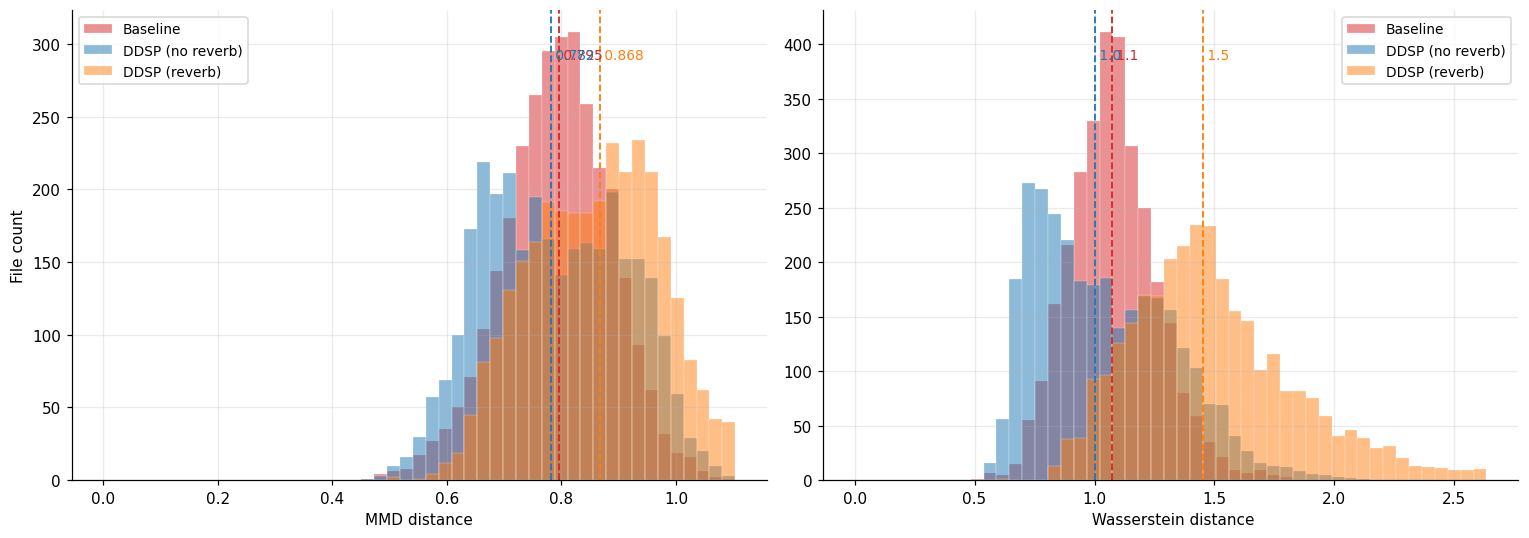

In [5]:
method_order = ["Baseline", "DDSP (no reverb)", "DDSP (reverb)"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── MMD histogram ─────────────────────────────────────────────────────
ax = axes[0]
bins_mmd = np.linspace(0, df_pw["mmd"].quantile(0.995), 50)
for method in method_order:
    vals = df_pw.loc[df_pw.method == method, "mmd"]
    ax.hist(vals, bins=bins_mmd, color=METHOD_COLOR[method], alpha=0.5, label=method, edgecolor="white", linewidth=0.3)
    med = vals.median()
    ax.axvline(med, color=METHOD_COLOR[method], linestyle="--", linewidth=1.2)
    ax.text(med, ax.get_ylim()[1] * 0.92 if ax.get_ylim()[1] > 0 else 1,
            f" {med:.3f}", color=METHOD_COLOR[method], fontsize=9, va="top")
ax.set_xlabel("MMD distance")
ax.set_ylabel("File count")
# ax.set_title("Per-file MMD distribution")
ax.legend(fontsize=9)

# ── Wasserstein histogram ─────────────────────────────────────────────
ax = axes[1]
bins_w = np.linspace(0, df_pw["wasserstein"].quantile(0.995), 50)
for method in method_order:
    vals = df_pw.loc[df_pw.method == method, "wasserstein"]
    ax.hist(vals, bins=bins_w, color=METHOD_COLOR[method], alpha=0.5, label=method, edgecolor="white", linewidth=0.3)
    med = vals.median()
    ax.axvline(med, color=METHOD_COLOR[method], linestyle="--", linewidth=1.2)
    ax.text(med, ax.get_ylim()[1] * 0.92 if ax.get_ylim()[1] > 0 else 1,
            f" {med:.1f}", color=METHOD_COLOR[method], fontsize=9, va="top")
ax.set_xlabel(" Wasserstein distance")
# ax.set_title("Per-file Wasserstein distribution")
ax.legend(fontsize=9)

fig.tight_layout()
fig.savefig(FIG_DIR / "timbre_perfile_distributions.png", dpi=160, bbox_inches="tight")
plt.show()

## 3b. Per-Feature Distance

Same MMD / Wasserstein comparison but evaluated on each 1-D feature
individually (loaded from `distribution_per_feature.csv` and
`pairwise_per_feature.csv`). Shows which individual spectral descriptors
drive the aggregate distance values reported above.

In [6]:
# ── Load per-feature results from both reverb / noreverb artifact dirs ──
df_glob_pf_noreverb = pd.read_csv(EVAL_NOREVERB / "distribution_per_feature.csv")
df_glob_pf_reverb   = pd.read_csv(EVAL_REVERB   / "distribution_per_feature.csv")

df_glob_pf = pd.concat([
    df_glob_pf_noreverb[df_glob_pf_noreverb.method == "baseline"].assign(method="Baseline"),
    df_glob_pf_noreverb[df_glob_pf_noreverb.method == "ddsp"].assign(method="DDSP (no reverb)"),
    df_glob_pf_reverb[df_glob_pf_reverb.method == "ddsp"].assign(method="DDSP (reverb)"),
], ignore_index=True)

df_pw_pf_noreverb = pd.read_csv(EVAL_NOREVERB / "pairwise_per_feature.csv")
df_pw_pf_reverb   = pd.read_csv(EVAL_REVERB   / "pairwise_per_feature.csv")

df_pw_pf = pd.concat([
    df_pw_pf_noreverb[df_pw_pf_noreverb.method == "baseline"].assign(method="Baseline"),
    df_pw_pf_noreverb[df_pw_pf_noreverb.method == "ddsp"].assign(method="DDSP (no reverb)"),
    df_pw_pf_reverb[df_pw_pf_reverb.method == "ddsp"].assign(method="DDSP (reverb)"),
], ignore_index=True)

# Short feature labels (strip "spectral_" prefix for readability)
df_glob_pf["feature_short"] = df_glob_pf["feature"].str.replace("spectral_", "", regex=False)
df_pw_pf["feature_short"]   = df_pw_pf["feature"].str.replace("spectral_", "", regex=False)

FEATURES_PF = df_glob_pf["feature"].unique().tolist()
FEATURES_PF_SHORT = [f.replace("spectral_", "") for f in FEATURES_PF]
METHOD_ORDER_PF  = ["Baseline", "DDSP (no reverb)", "DDSP (reverb)"]

print(f"Per-feature global: {len(df_glob_pf)} rows, features={FEATURES_PF_SHORT}")
print(f"Per-feature pairwise: {len(df_pw_pf)} rows")

Per-feature global: 21 rows, features=['centroid', 'crest', 'decrease', 'flatness', 'roll_off', 'skewness', 'spread']
Per-feature pairwise: 64974 rows


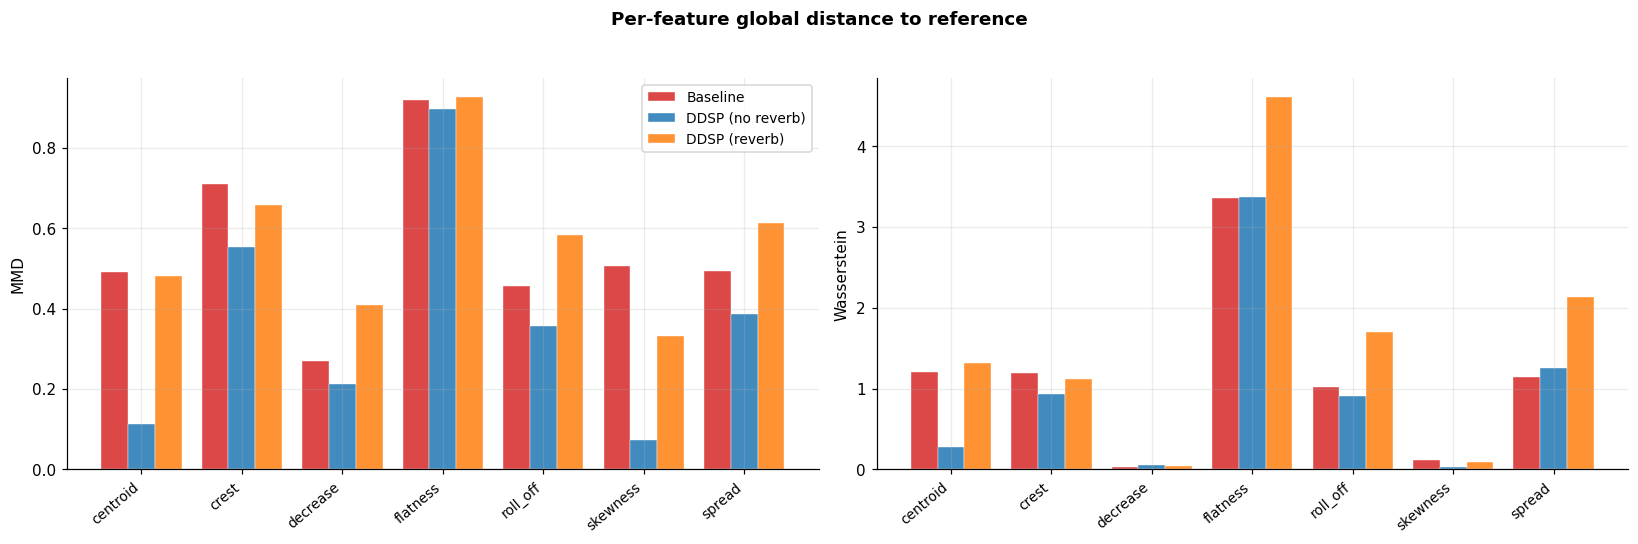

In [20]:
# ── Global per-feature: grouped bars for MMD and Wasserstein ───────────
# MMD is unit-less and comparable across features; Wasserstein scales with
# the feature's native range so we plot it on a log-y axis.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = np.arange(len(FEATURES_PF))
n = len(METHOD_ORDER_PF)
width = 0.8 / n

for metric_idx, (metric, ylabel, logy) in enumerate(
    [("mmd", "MMD", False), ("wasserstein", "Wasserstein", True)]
):
    ax = axes[metric_idx]
    for j, method in enumerate(METHOD_ORDER_PF):
        vals = [
            df_glob_pf.query("method == @method and feature == @f")[metric].iloc[0]
            for f in FEATURES_PF
        ]
        offset = x + (j - (n - 1) / 2) * width
        ax.bar(offset, vals, width, label=method,
               color=METHOD_COLOR[method], alpha=0.85,
               edgecolor="white", linewidth=0.3)
    ax.set_xticks(x)
    ax.set_xticklabels(FEATURES_PF_SHORT, rotation=40, ha="right", fontsize=9)
    ax.set_ylabel(ylabel)
    # if logy:
    #     ax.set_yscale("log")
    if metric_idx == 0:
        ax.legend(fontsize=9)

fig.suptitle("Per-feature global distance to reference", fontweight="bold", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(FIG_DIR / "timbre_perfeature_global.png", dpi=160, bbox_inches="tight")
plt.show()

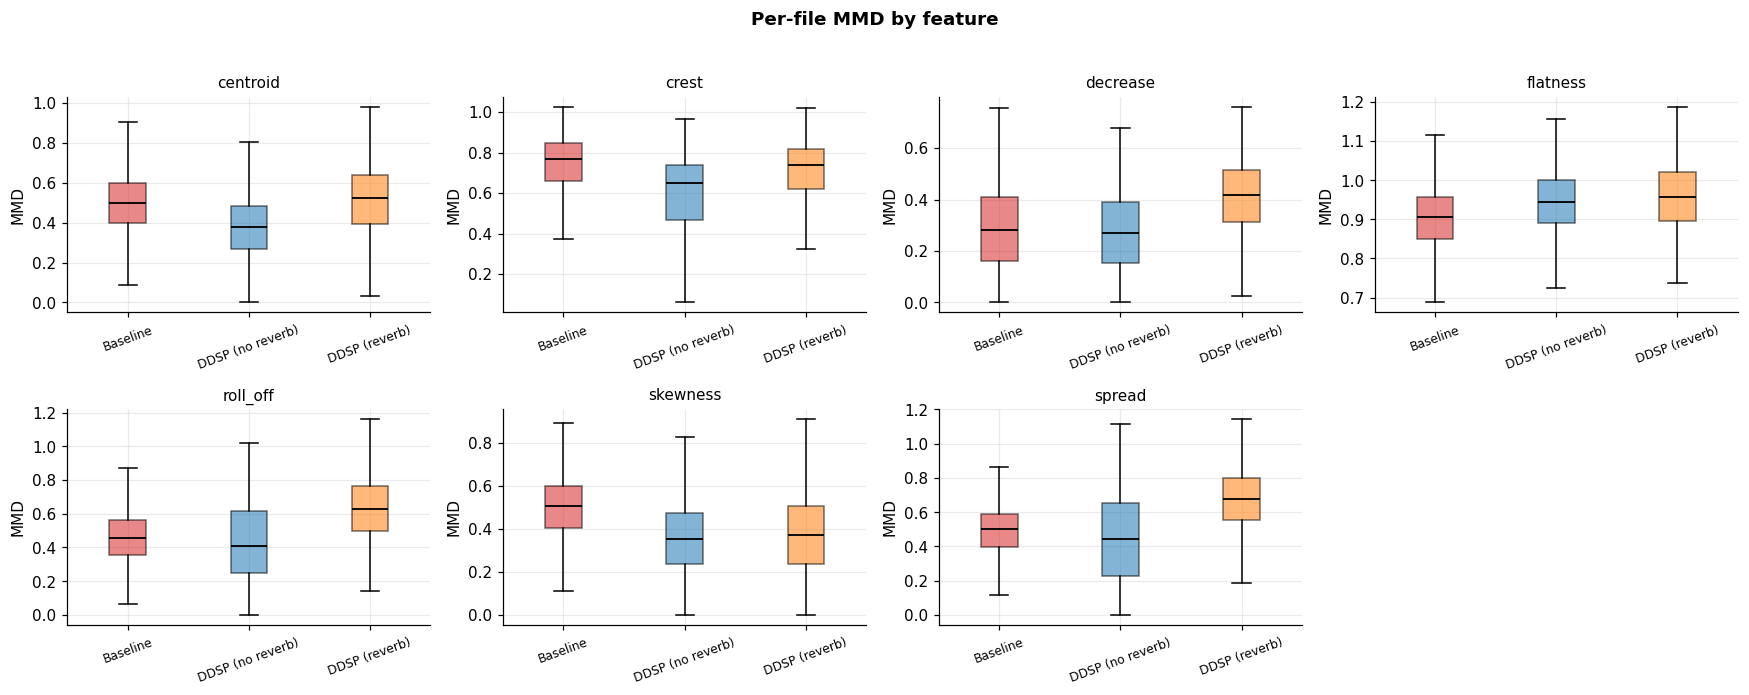

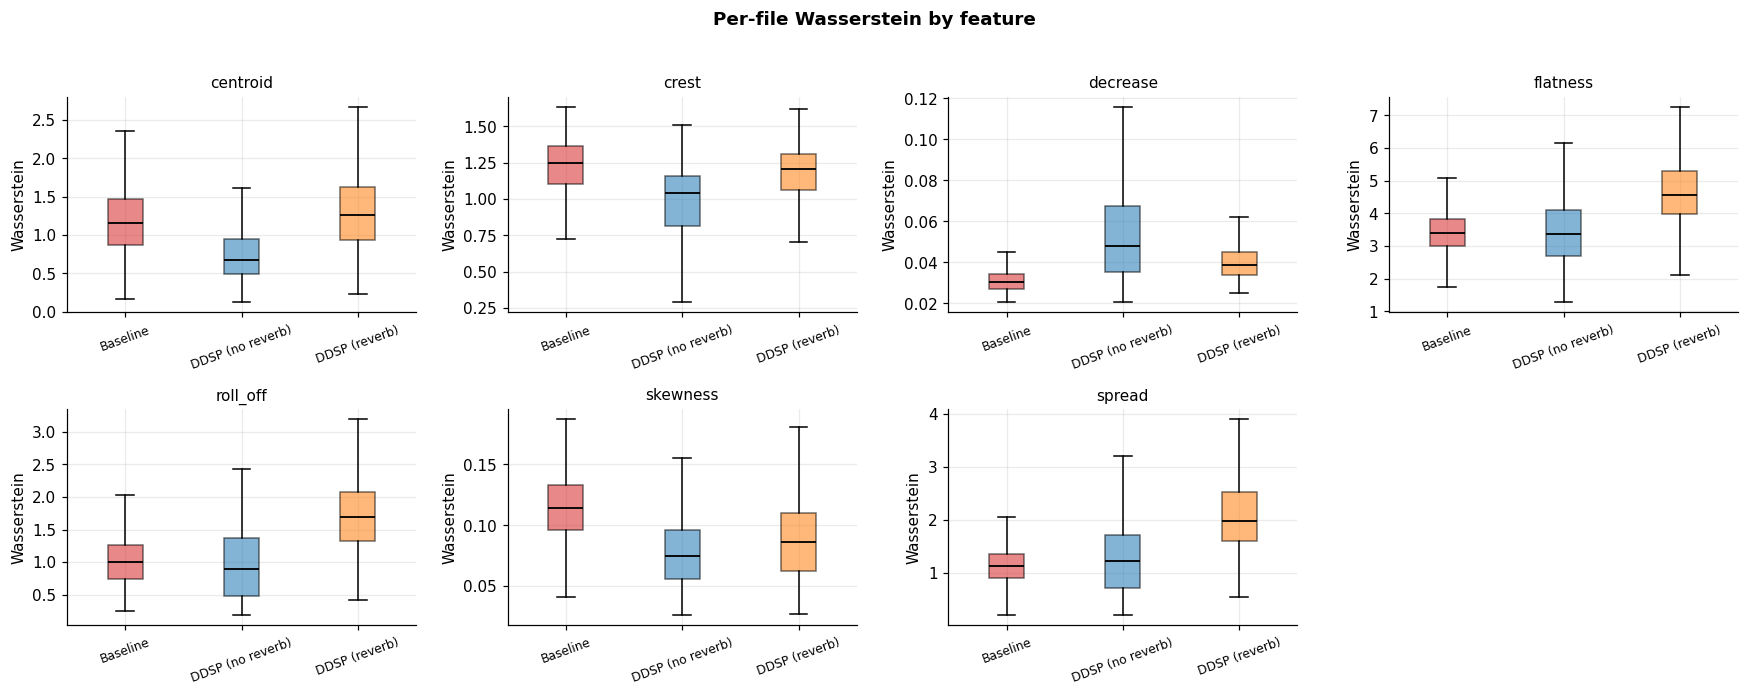

In [21]:
# ── Pairwise per-feature: small-multiple boxplots ─────────────────────
# One panel per feature, one box per method (3 boxes). Separate figure
# per metric since MMD and Wasserstein have different scales.
for metric, ylabel in [("mmd", "MMD"), ("wasserstein", "Wasserstein")]:
    n_feats = len(FEATURES_PF)
    ncols = 4
    nrows = int(np.ceil(n_feats / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows))
    axes = axes.flatten()

    for i, (ax, feat, feat_short) in enumerate(zip(axes, FEATURES_PF, FEATURES_PF_SHORT)):
        data = [
            df_pw_pf.query("method == @method and feature == @feat")[metric].values
            for method in METHOD_ORDER_PF
        ]
        bp = ax.boxplot(
            data, tick_labels=METHOD_ORDER_PF, showfliers=False, patch_artist=True,
        )
        for patch, method in zip(bp["boxes"], METHOD_ORDER_PF):
            patch.set_facecolor(METHOD_COLOR[method])
            patch.set_alpha(0.55)
        for median in bp["medians"]:
            median.set_color("black")
            median.set_linewidth(1.2)
        ax.set_title(feat_short, fontsize=10)
        ax.set_ylabel(ylabel)
        ax.tick_params(axis="x", rotation=20, labelsize=8)

    # Hide any unused subplots
    for ax in axes[n_feats:]:
        ax.set_visible(False)

    fig.suptitle(f"Per-file {ylabel} by feature", fontweight="bold", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig(FIG_DIR / f"timbre_perfeature_pairwise_{metric}.png", dpi=160, bbox_inches="tight")
    plt.show()

---
# Pitch--Timbre Coupling Results

Sections 4–6 report the coupling model results. Data is loaded from
pickle files (full model dicts) so that NMSE, standardized coefficient
distance, and OLS standard errors are all available.

In [22]:
import pickle

DESCRIPTORS = [
    "spectral_centroid", "spectral_crest", "spectral_decrease",
    "spectral_flatness", "spectral_roll_off", "spectral_skewness",
    "spectral_spread",
]
DESC_SHORT = [d.replace("spectral_", "") for d in DESCRIPTORS]

# Both correlation metrics are loaded and displayed side-by-side.
# Upstream coupling_analysis.ipynb computes both with method="both" and saves
# Pearson at exp2_correlation_summary_log2.csv and Spearman at *_log2_spearman.csv.
CORR_METHODS = ("pearson", "spearman")

# ── Load reference model (same in both dirs) ──────────────────────────
# ref_corr is dict[descriptor] -> {pearson_r, pearson_p, spearman_r, spearman_p}
with open(EVAL_REVERB / "exp1_ref_coupling_models_log2.pkl", "rb") as f:
    ref_bundle = pickle.load(f)
ref_models = ref_bundle["models"]
ref_corr   = ref_bundle["correlation"]

# ── Load method models (regression coefficients — method-agnostic) ────
with open(EVAL_NOREVERB / "exp2_method_models_log2.pkl", "rb") as f:
    models_noreverb = pickle.load(f)   # {"ddsp": {...}, "baseline": {...}}
with open(EVAL_REVERB / "exp2_method_models_log2.pkl", "rb") as f:
    models_reverb = pickle.load(f)

# Unified dict: method_label → {descriptor → model_dict}
all_method_models = {
    "DDSP (no reverb)": models_noreverb["ddsp"],
    "DDSP (reverb)":    models_reverb["ddsp"],
    "Baseline":         models_noreverb["baseline"],  # same in both
}

# ── Load coupling error CSVs (raw MSE) ────────────────────────────────
ce_noreverb = pd.read_csv(EVAL_NOREVERB / "exp2_coupling_error_log2.csv", index_col=0)
ce_reverb   = pd.read_csv(EVAL_REVERB   / "exp2_coupling_error_log2.csv", index_col=0)

# Compute NMSE = MSE / Var(ref)  where Var(ref) = y_std²
ref_var = {d: ref_models[d]["y_std"] ** 2 for d in DESCRIPTORS}

nmse = {}
for d in DESCRIPTORS:
    v = ref_var[d]
    nmse[d] = {
        "DDSP (no reverb)": ce_noreverb.loc["ddsp", d] / v,
        "DDSP (reverb)":    ce_reverb.loc["ddsp", d] / v,
        "Baseline":         ce_noreverb.loc["baseline", d] / v,
    }
df_nmse = pd.DataFrame(nmse).T
df_nmse.index.name = "descriptor"

# ── Compute standardized coefficient distance ─────────────────────────
def _std_coeff_dist(method_models_dict, ref_models, descriptors):
    dist = {}
    for d in descriptors:
        m = method_models_dict[d]
        r = ref_models[d]
        diff = m["coeffs"] - r["coeffs"]
        y_std = r["y_std"]
        x_std = r["x_std"]
        scale = np.asarray(x_std, dtype=np.float64) / y_std
        dist[d] = float(np.linalg.norm(diff[1:] * scale))
    return dist

std_cd = {}
for label, mdict in all_method_models.items():
    std_cd[label] = _std_coeff_dist(mdict, ref_models, DESCRIPTORS)
df_std_cd = pd.DataFrame(std_cd)
df_std_cd.index.name = "descriptor"

# ── Load dynamics data ────────────────────────────────────────────────
df_dyn_noreverb = pd.read_csv(EVAL_NOREVERB / "exp3_dynamics_coefficients_log2.csv")
df_dyn_reverb   = pd.read_csv(EVAL_REVERB   / "exp3_dynamics_coefficients_log2.csv")
df_dd_noreverb  = pd.read_csv(EVAL_NOREVERB / "exp3_dynamics_distance_log2.csv")
df_dd_reverb    = pd.read_csv(EVAL_REVERB   / "exp3_dynamics_distance_log2.csv")

# Combine dynamics into unified frames
def _relabel_dyn(df, ddsp_label):
    df = df.copy()
    df.loc[df.method == "ddsp", "method"] = ddsp_label
    df.loc[df.method == "baseline", "method"] = "Baseline"
    df.loc[df.method == "reference", "method"] = "Reference"
    return df

df_dyn = pd.concat([
    _relabel_dyn(df_dyn_noreverb, "DDSP (no reverb)"),
    _relabel_dyn(df_dyn_reverb[df_dyn_reverb.method == "ddsp"], "DDSP (reverb)"),
]).drop_duplicates(subset=["method", "descriptor"])

df_dd = pd.concat([
    df_dd_noreverb[df_dd_noreverb.method == "ddsp"].assign(method="DDSP (no reverb)"),
    df_dd_reverb[df_dd_reverb.method == "ddsp"].assign(method="DDSP (reverb)"),
    df_dd_noreverb[df_dd_noreverb.method == "baseline"].assign(method="Baseline"),
]).drop_duplicates(subset=["method", "descriptor"])

# ── Load correlation data: both Pearson and Spearman ──────────────────
# Pearson keeps the historical filename; Spearman has a "_spearman" suffix.
CORR_CSV_SUFFIX = {"pearson": "", "spearman": "_spearman"}

df_corr_by_method = {}
for m in CORR_METHODS:
    corr_norev = pd.read_csv(
        EVAL_NOREVERB / f"exp2_correlation_summary_log2{CORR_CSV_SUFFIX[m]}.csv",
        index_col=0,
    )
    corr_rev = pd.read_csv(
        EVAL_REVERB / f"exp2_correlation_summary_log2{CORR_CSV_SUFFIX[m]}.csv",
        index_col=0,
    )
    df_corr_by_method[m] = pd.DataFrame({
        "Reference":        corr_norev.loc["reference", DESCRIPTORS],
        "DDSP (no reverb)": corr_norev.loc["ddsp", DESCRIPTORS],
        "DDSP (reverb)":    corr_rev.loc["ddsp", DESCRIPTORS],
        "Baseline":         corr_norev.loc["baseline", DESCRIPTORS],
    })
    df_corr_by_method[m].index.name = "descriptor"

# Backward-compatible alias (Pearson) for any downstream cell that still
# references a single df_corr.
df_corr = df_corr_by_method["pearson"]

print(f"All coupling data loaded.  (correlation metrics: {list(CORR_METHODS)})")


All coupling data loaded.  (correlation metrics: ['pearson', 'spearman'])


## 4. Reference Coupling Model

**Table 1** — Reference coupling coefficients and $R^2$. Shows how
strongly pitch--timbre coupling is present in the reference before any
method is evaluated.

In [23]:
# Table 1: Reference coupling coefficients, R², and descriptor↔pitch correlation
# (both Pearson r and Spearman r reported side-by-side).
rows_t1 = []
for d in DESCRIPTORS:
    m = ref_models[d]
    rows_t1.append({
        "descriptor": d.replace("spectral_", ""),
        "β₁": m["coeffs"][1],
        "β₂": m["coeffs"][2],
        "β₃": m["coeffs"][3],
        "R²": m["r2"],
        "Pearson r":  ref_corr[d]["pearson_r"],
        "Spearman r": ref_corr[d]["spearman_r"],
    })
df_t1 = pd.DataFrame(rows_t1).set_index("descriptor")
display(df_t1.round(4))

# ── LaTeX ─────────────────────────────────────────────────────────────
lines = [
    r"\begin{table}[ht]",
    r"\centering",
    r"\caption{Reference coupling model: coefficients, goodness of fit, and "
    r"descriptor$\leftrightarrow$pitch correlation (Pearson and Spearman).}",
    r"\label{tab:ref-coupling}",
    r"\begin{tabular}{lcccccc}",
    r"\toprule",
    r"Descriptor & $\beta_1$ & $\beta_2$ & $\beta_3$ & $R^2$ & "
    r"Pearson $r$ & Spearman $r$ \\",
    r"\midrule",
]
for _, row in df_t1.iterrows():
    lines.append(
        f"{row.name} & {row['β₁']:.2f} & {row['β₂']:.2f} & {row['β₃']:.4f} "
        f"& {row['R²']:.3f} & {row['Pearson r']:+.3f} & {row['Spearman r']:+.3f} \\\\"
    )
lines += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]
print("\n".join(lines))


,β₁,β₂,β₃,R²,Pearson r,Spearman r
descriptor,,,,,,
centroid,0.8906,0.0800,0.0042,0.3029,0.5364,0.5599
crest,-0.0714,-0.0120,0.0007,0.0020,-0.0378,-0.0460
decrease,-0.0067,-0.0009,-0.0001,0.0037,-0.0664,-0.4381
flatness,0.1617,-0.0051,0.0003,0.0120,0.1021,0.1086
roll_off,0.7430,0.0876,0.0038,0.2161,0.4425,0.4743
skewness,-0.0537,-0.0044,-0.0003,0.1280,-0.3543,-0.3802
spread,0.5469,0.0787,0.0033,0.1202,0.3237,0.3535


\begin{table}[ht]
\centering
\caption{Reference coupling model: coefficients, goodness of fit, and descriptor$\leftrightarrow$pitch correlation (Pearson and Spearman).}
\label{tab:ref-coupling}
\begin{tabular}{lcccccc}
\toprule
Descriptor & $\beta_1$ & $\beta_2$ & $\beta_3$ & $R^2$ & Pearson $r$ & Spearman $r$ \\
\midrule
centroid & 0.89 & 0.08 & 0.0042 & 0.303 & +0.536 & +0.560 \\
crest & -0.07 & -0.01 & 0.0007 & 0.002 & -0.038 & -0.046 \\
decrease & -0.01 & -0.00 & -0.0001 & 0.004 & -0.066 & -0.438 \\
flatness & 0.16 & -0.01 & 0.0003 & 0.012 & +0.102 & +0.109 \\
roll_off & 0.74 & 0.09 & 0.0038 & 0.216 & +0.443 & +0.474 \\
skewness & -0.05 & -0.00 & -0.0003 & 0.128 & -0.354 & -0.380 \\
spread & 0.55 & 0.08 & 0.0033 & 0.120 & +0.324 & +0.353 \\
\bottomrule
\end{tabular}
\end{table}


,r(β₁),p(β₁),r(β₂),p(β₂),r(β₃),p(β₃)
descriptor,,,,,,
centroid,0.5469,0.0,0.0758,0.0000,0.0315,0.0000
crest,-0.0426,0.0,-0.0093,0.0918,0.0044,0.4272
decrease,-0.0605,0.0,-0.0108,0.0506,-0.0071,0.1955
flatness,0.1082,0.0,-0.0045,0.4174,0.0020,0.7144
roll_off,0.4604,0.0,0.0789,0.0000,0.0272,0.0000
skewness,-0.3552,0.0,-0.0400,0.0000,-0.0189,0.0006
spread,0.3420,0.0,0.0677,0.0000,0.0229,0.0000


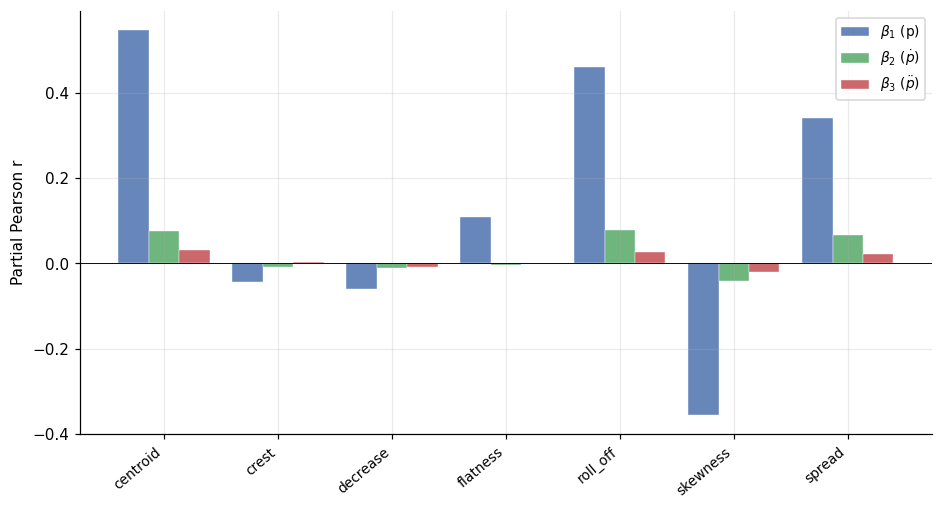

In [24]:
# Figure: per-coefficient Pearson r and p-value of the reference model.
# Per-coefficient (partial) Pearson r is derived from the OLS t-statistic:
#     r_partial = t / sqrt(t^2 + df),  df = n - k
# which equals Pearson r in single-regressor OLS and is the correct
# per-coefficient correlation analog under multiple regression.
coef_names = [r"$\beta_1$ (p)", r"$\beta_2$ ($\dot p$)", r"$\beta_3$ ($\ddot p$)"]
coef_slots = [1, 2, 3]  # skip intercept
coef_colors = ["#4c72b0", "#55a868", "#c44e52"]

C_REF_FIG = "#2c3e50"
# all_labels = ["Reference", "DDSP (no reverb)", "DDSP (reverb)", "Baseline"]
fig_colors = {
    "Reference": C_REF_FIG,
    "DDSP (no reverb)": C_DDSP,
    "DDSP (reverb)": C_DDSP_R,
    "Baseline": C_BASE,
}

partial_r = np.full((len(DESCRIPTORS), 3), np.nan)
pvals     = np.full((len(DESCRIPTORS), 3), np.nan)
for i, d in enumerate(DESCRIPTORS):
    m = ref_models[d]
    df_resid = m["n"] - m["k"]
    for jj, ci in enumerate(coef_slots):
        t_val = m["t_values"][ci]
        if np.isfinite(t_val) and df_resid > 0:
            partial_r[i, jj] = t_val / np.sqrt(t_val ** 2 + df_resid)
        pvals[i, jj] = m["p_values"][ci]

fig, axes = plt.subplots(1, 1, figsize=(10, 5))
x = np.arange(len(DESCRIPTORS))
width = 0.8 / 3

# ── Panel 1: partial Pearson r per coefficient ───────────────────────
ax = axes
for jj, cname in enumerate(coef_names):
    ax.bar(x + (jj - 1) * width, partial_r[:, jj], width,
           label=cname, color=coef_colors[jj], alpha=0.85,
           edgecolor="white", linewidth=0.3)
ax.set_xticks(x)
ax.set_xticklabels(DESC_SHORT, rotation=40, ha="right", fontsize=9)
ax.axhline(0, color="black", linewidth=0.6)
ax.set_ylabel("Partial Pearson r")
# ax.set_title("Per-coefficient partial correlation (reference)")
ax.legend(fontsize=9)

# # ── Panel 2: -log10(p) per coefficient ───────────────────────────────
# ax = axes[1]
# neg_log_p = -np.log10(np.clip(pvals, 1e-300, 1.0))
# for jj, cname in enumerate(coef_names):
#     ax.bar(x + (jj - 1) * width, neg_log_p[:, jj], width,
#            label=cname, color=coef_colors[jj], alpha=0.85,
#            edgecolor="white", linewidth=0.3)
# ax.set_xticks(x)
# ax.set_xticklabels(DESC_SHORT, rotation=40, ha="right", fontsize=9)
# ax.axhline(-np.log10(0.05), color="red", linewidth=1, linestyle="--",
#            label=r"$p=0.05$")
# ax.set_ylabel(r"$-\log_{10}(p)$")
# ax.set_title("Per-coefficient significance (OLS t-test, reference)")
ax.legend(fontsize=9)

# fig.tight_layout()
# fig.savefig(FIG_DIR / "reference_coupling_per_coef_stats.png", dpi=160, bbox_inches="tight")
# plt.show()

# Also display a tidy table of the numeric values.
rows_stat = []
for i, d in enumerate(DESCRIPTORS):
    row = {"descriptor": d.replace("spectral_", "")}
    for jj, cname in enumerate(["β₁", "β₂", "β₃"]):
        row[f"r({cname})"] = partial_r[i, jj]
        row[f"p({cname})"] = pvals[i, jj]
    rows_stat.append(row)
df_ref_coef_stats = pd.DataFrame(rows_stat).set_index("descriptor")
display(df_ref_coef_stats.round(4))


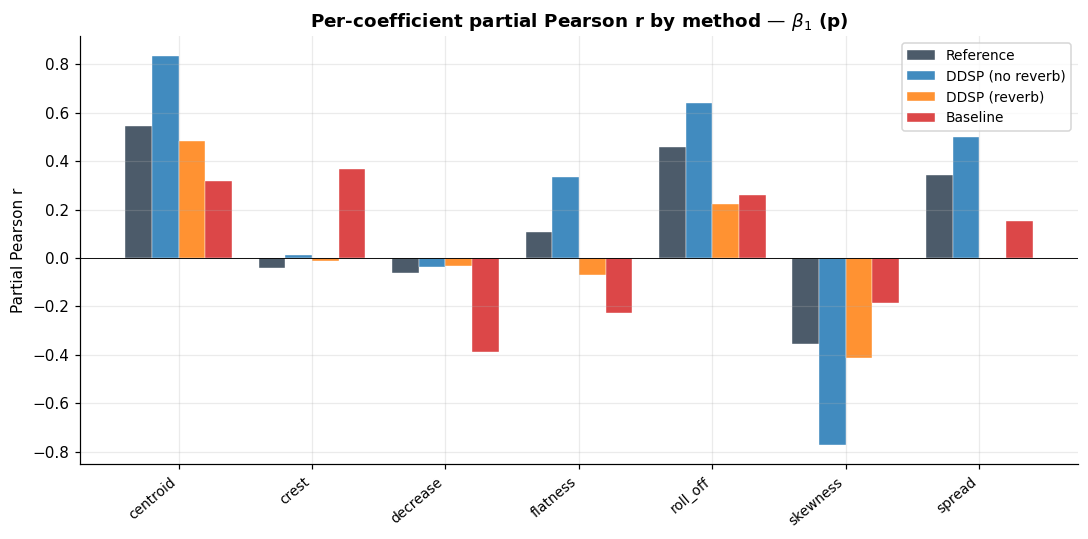

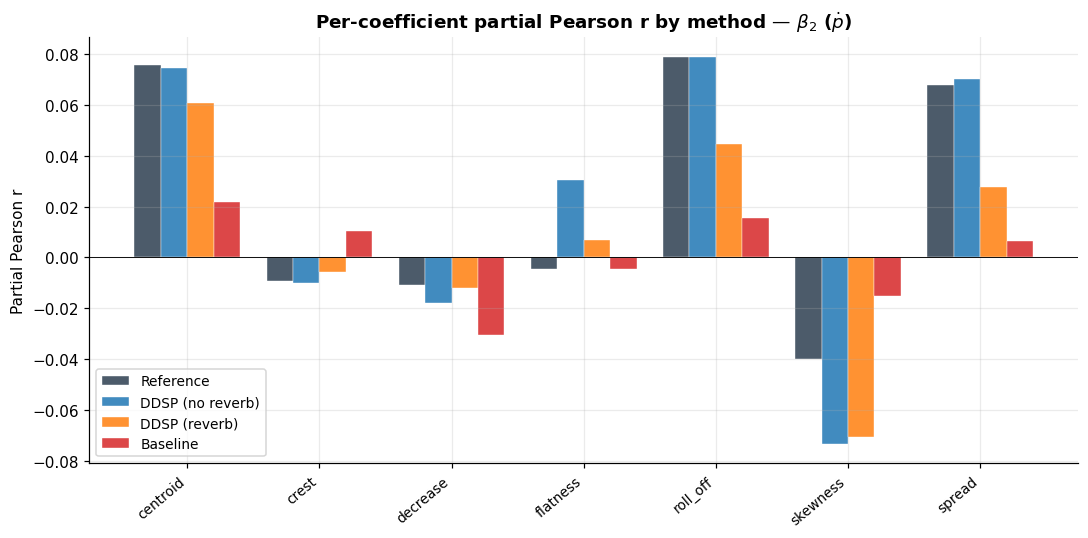

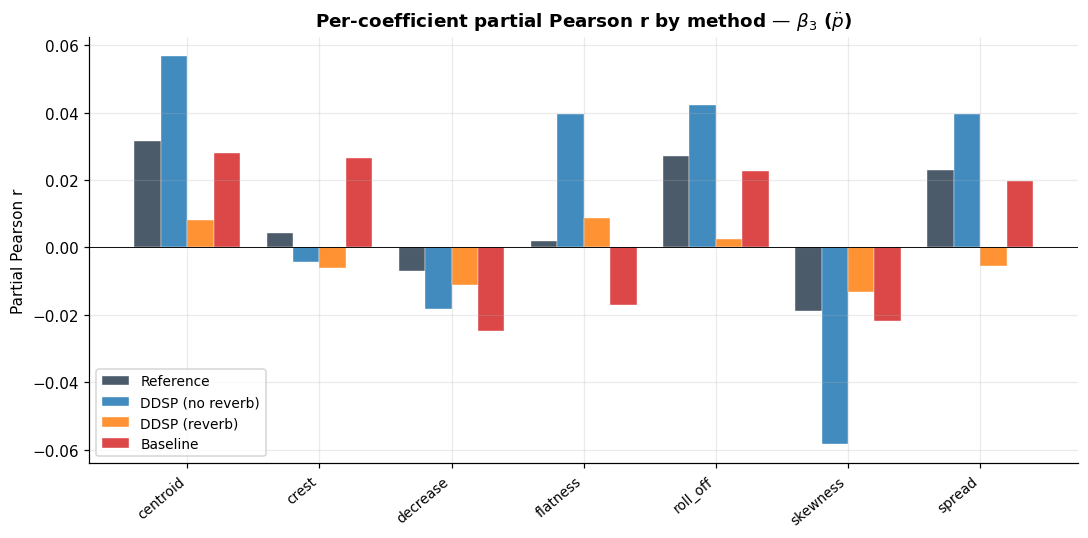

In [25]:
# Figure: per-coefficient partial Pearson r across methods (3 separate figures).
# Uses the same t-to-partial-r conversion as the reference-model figure:
#     r_partial = t / sqrt(t^2 + df),  df = n - k
def _partial_r_table(models_dict):
    """Return (n_desc, 3) array of partial r for β₁..β₃."""
    r = np.full((len(DESCRIPTORS), 3), np.nan)
    for i, d in enumerate(DESCRIPTORS):
        m = models_dict[d]
        df_resid = m["n"] - m["k"]
        for jj, ci in enumerate([1, 2, 3]):
            t_val = m["t_values"][ci]
            if np.isfinite(t_val) and df_resid > 0:
                r[i, jj] = t_val / np.sqrt(t_val ** 2 + df_resid)
    return r

method_order_all = ["Reference", "DDSP (no reverb)", "DDSP (reverb)", "Baseline"]
models_by_label = {
    "Reference":        ref_models,
    "DDSP (no reverb)": all_method_models["DDSP (no reverb)"],
    "DDSP (reverb)":    all_method_models["DDSP (reverb)"],
    "Baseline":         all_method_models["Baseline"],
}
r_by_method = {lab: _partial_r_table(m) for lab, m in models_by_label.items()}

coef_names = [r"$\beta_1$ (p)", r"$\beta_2$ ($\dot p$)", r"$\beta_3$ ($\ddot p$)"]
coef_slugs = ["beta1_p", "beta2_pdot", "beta3_pddot"]
x = np.arange(len(DESCRIPTORS))
n_m = len(method_order_all)
width = 0.8 / n_m

for ci_idx, (cname, slug) in enumerate(zip(coef_names, coef_slugs)):
    fig, ax = plt.subplots(figsize=(10, 5))
    for j, label in enumerate(method_order_all):
        vals = r_by_method[label][:, ci_idx]
        offset = x + (j - (n_m - 1) / 2) * width
        ax.bar(offset, vals, width, label=label,
               color=fig_colors[label], alpha=0.85,
               edgecolor="white", linewidth=0.3)
    ax.set_xticks(x)
    ax.set_xticklabels(DESC_SHORT, rotation=40, ha="right", fontsize=9)
    ax.axhline(0, color="black", linewidth=0.6)
    ax.set_ylabel("Partial Pearson r")
    ax.set_title(f"Per-coefficient partial Pearson r by method — {cname}",
                 fontweight="bold", fontsize=12)
    ax.legend(fontsize=9, loc="best")
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"coupling_partial_r_{slug}.png", dpi=160, bbox_inches="tight")
    plt.show()


In [26]:
# Table: per-coefficient partial Pearson r across methods.
table = {}
for label in method_order_all:
    for jj, cname in enumerate(["β₁", "β₂", "β₃"]):
        table[(label, cname)] = r_by_method[label][:, jj]
df_partial_r = pd.DataFrame(table, index=DESC_SHORT)
df_partial_r.index.name = "descriptor"
df_partial_r.columns = pd.MultiIndex.from_tuples(df_partial_r.columns,
                                                 names=["method", "coefficient"])
display(df_partial_r.round(3))

# ── LaTeX table (methods as row groups, coefficients as columns) ────
lines = [
    r"\begin{table}[ht]",
    r"\centering",
    r"\caption{Per-coefficient partial Pearson $r$ across methods.}",
    r"\label{tab:partial-r-methods}",
    r"\begin{tabular}{ll" + "c" * len(DESCRIPTORS) + "}",
    r"\toprule",
    "Method & Coef. & " + " & ".join(s.replace("_", r"\_") for s in DESC_SHORT) + r" \\",
    r"\midrule",
]
for label in method_order_all:
    for jj, cname in enumerate([r"$\beta_1$", r"$\beta_2$", r"$\beta_3$"]):
        row_vals = " & ".join(f"{v:+.3f}" for v in r_by_method[label][:, jj])
        prefix = label if jj == 0 else ""
        lines.append(f"{prefix} & {cname} & {row_vals} \\\\")
    lines.append(r"\midrule")
lines[-1] = r"\bottomrule"
lines += [r"\end{tabular}", r"\end{table}"]
print("\n".join(lines))


method      Reference               DDSP (no reverb)                \
coefficient        β₁     β₂     β₃               β₁     β₂     β₃   
descriptor                                                           
centroid        0.547  0.076  0.032            0.837  0.074  0.057   
crest          -0.043 -0.009  0.004            0.011 -0.010 -0.004   
decrease       -0.060 -0.011 -0.007           -0.036 -0.018 -0.018   
flatness        0.108 -0.004  0.002            0.335  0.030  0.040   
roll_off        0.460  0.079  0.027            0.640  0.079  0.042   
skewness       -0.355 -0.040 -0.019           -0.772 -0.073 -0.058   
spread          0.342  0.068  0.023            0.499  0.070  0.039   

method      DDSP (reverb)               Baseline                
coefficient            β₁     β₂     β₃       β₁     β₂     β₃  
descriptor                                                      
centroid            0.482  0.061  0.008    0.319  0.022  0.028  
crest              -0.012 -0.006 -0.006    0.368  0.010  0.027  
decrease           -0.034 -0.012 -0.011   -0.387 -0.031 -0.025  
flatness           -0.069  0.007  0.009   -0.228 -0.005 -0.017  
roll_off            0.223  0.045  0.002    0.260  0.015  0.023  
skewness           -0.414 -0.071 -0.013   -0.187 -0.015 -0.022  
spread             -0.002  0.028 -0.005    0.151  0.007  0.020

\begin{table}[ht]
\centering
\caption{Per-coefficient partial Pearson $r$ across methods.}
\label{tab:partial-r-methods}
\begin{tabular}{llccccccc}
\toprule
Method & Coef. & centroid & crest & decrease & flatness & roll\_off & skewness & spread \\
\midrule
Reference & $\beta_1$ & +0.547 & -0.043 & -0.060 & +0.108 & +0.460 & -0.355 & +0.342 \\
 & $\beta_2$ & +0.076 & -0.009 & -0.011 & -0.004 & +0.079 & -0.040 & +0.068 \\
 & $\beta_3$ & +0.032 & +0.004 & -0.007 & +0.002 & +0.027 & -0.019 & +0.023 \\
\midrule
DDSP (no reverb) & $\beta_1$ & +0.837 & +0.011 & -0.036 & +0.335 & +0.640 & -0.772 & +0.499 \\
 & $\beta_2$ & +0.074 & -0.010 & -0.018 & +0.030 & +0.079 & -0.073 & +0.070 \\
 & $\beta_3$ & +0.057 & -0.004 & -0.018 & +0.040 & +0.042 & -0.058 & +0.039 \\
\midrule
DDSP (reverb) & $\beta_1$ & +0.482 & -0.012 & -0.034 & -0.069 & +0.223 & -0.414 & -0.002 \\
 & $\beta_2$ & +0.061 & -0.006 & -0.012 & +0.007 & +0.045 & -0.071 & +0.028 \\
 & $\beta_3$ & +0.008 & -0.006 & -0.011 & +0.009 & +0.0

## 5. Coupling Reproduction

**Table 2** — NMSE per method per descriptor (bold = lowest).
**Table 3** — Standardised coefficient distance (bold = lowest).
**Figure 1** — Coefficient comparison bar chart (β₁, β₂, β₃).
**Figure 2** — Pearson correlation comparison.

In [27]:
# Table 2: NMSE per method per descriptor (+ reference self-NMSE = 1 - R²)
method_cols = ["DDSP (no reverb)", "DDSP (reverb)", "Baseline"]

# Add reference self-NMSE column
df_nmse["Reference"] = pd.Series({d: 1 - ref_models[d]["r2"] for d in DESCRIPTORS})
all_cols = ["Reference"] + method_cols
display(df_nmse[all_cols].round(4))

def _latex_bold_min(df, cols, fmt=".4f"):
    """Return LaTeX table rows, bolding the lowest value per row."""
    lines = []
    for idx, row in df.iterrows():
        vals = [row[c] for c in cols]
        min_val = min(vals)
        parts = []
        for v in vals:
            s = f"{v:{fmt}}"
            parts.append(r"\textbf{" + s + "}" if v == min_val else s)
        name = idx.replace("spectral_", "").replace("_", r"\_")
        lines.append(f"{name} & " + " & ".join(parts) + r" \\")
    return lines

lines = [
    r"\begin{table}[ht]",
    r"\centering",
    r"\caption{Coupling error (NMSE) per descriptor. Bold indicates the lowest value per row (excluding reference).}",
    r"\label{tab:nmse}",
    r"\begin{tabular}{lcccc}",
    r"\toprule",
    r"Descriptor & Reference & DDSP (no rev.) & DDSP (rev.) & Baseline \\",
    r"\midrule",
]
for idx, row in df_nmse.iterrows():
    name = idx.replace("spectral_", "").replace("_", r"\_")
    ref_val = f"{row['Reference']:.4f}"
    # Bold min among methods only
    method_vals = [row[c] for c in method_cols]
    min_val = min(method_vals)
    parts = []
    for v in method_vals:
        s = f"{v:.4f}"
        parts.append(r"\textbf{" + s + "}" if v == min_val else s)
    lines.append(f"{name} & {ref_val} & " + " & ".join(parts) + r" \\")
lines += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]
print("\n".join(lines))

,Reference,DDSP (no reverb),DDSP (reverb),Baseline
descriptor,,,,
spectral_centroid,0.6971,1.1654,2.9716,4.0620
spectral_crest,0.9980,1.2336,1.3991,1.8280
spectral_decrease,0.9963,0.4332,0.4060,0.0759
spectral_flatness,0.9880,14.1137,23.2386,17.6398
spectral_roll_off,0.7839,2.0135,4.1682,3.1384
spectral_skewness,0.8720,0.6935,1.3198,2.8212
spectral_spread,0.8798,2.3269,5.7239,3.3528


\begin{table}[ht]
\centering
\caption{Coupling error (NMSE) per descriptor. Bold indicates the lowest value per row (excluding reference).}
\label{tab:nmse}
\begin{tabular}{lcccc}
\toprule
Descriptor & Reference & DDSP (no rev.) & DDSP (rev.) & Baseline \\
\midrule
centroid & 0.6971 & \textbf{1.1654} & 2.9716 & 4.0620 \\
crest & 0.9980 & \textbf{1.2336} & 1.3991 & 1.8280 \\
decrease & 0.9963 & 0.4332 & 0.4060 & \textbf{0.0759} \\
flatness & 0.9880 & \textbf{14.1137} & 23.2386 & 17.6398 \\
roll\_off & 0.7839 & \textbf{2.0135} & 4.1682 & 3.1384 \\
skewness & 0.8720 & \textbf{0.6935} & 1.3198 & 2.8212 \\
spread & 0.8798 & \textbf{2.3269} & 5.7239 & 3.3528 \\
\bottomrule
\end{tabular}
\end{table}


In [28]:
# Table 3: Standardized coefficient distance
display(df_std_cd[method_cols].round(4))

lines = [
    r"\begin{table}[ht]",
    r"\centering",
    r"\caption{Standardised coefficient distance to reference. Bold indicates the lowest value per row.}",
    r"\label{tab:coeff-dist}",
    r"\begin{tabular}{lccc}",
    r"\toprule",
    r"Descriptor & DDSP (no rev.) & DDSP (rev.) & Baseline \\",
    r"\midrule",
    *_latex_bold_min(df_std_cd, method_cols),
    r"\bottomrule",
    r"\end{tabular}",
    r"\end{table}",
]
print("\n".join(lines))

,DDSP (no reverb),DDSP (reverb),Baseline
descriptor,,,
spectral_centroid,0.2227,0.0281,0.3111
spectral_crest,0.0489,0.0385,0.1679
spectral_decrease,0.0459,0.0381,0.0172
spectral_flatness,0.3536,0.2617,0.3981
spectral_roll_off,0.0694,0.1900,0.2938
spectral_skewness,0.3858,0.0450,0.2452
spectral_spread,0.1032,0.3509,0.2426


\begin{table}[ht]
\centering
\caption{Standardised coefficient distance to reference. Bold indicates the lowest value per row.}
\label{tab:coeff-dist}
\begin{tabular}{lccc}
\toprule
Descriptor & DDSP (no rev.) & DDSP (rev.) & Baseline \\
\midrule
centroid & 0.2227 & \textbf{0.0281} & 0.3111 \\
crest & 0.0489 & \textbf{0.0385} & 0.1679 \\
decrease & 0.0459 & 0.0381 & \textbf{0.0172} \\
flatness & 0.3536 & \textbf{0.2617} & 0.3981 \\
roll\_off & \textbf{0.0694} & 0.1900 & 0.2938 \\
skewness & 0.3858 & \textbf{0.0450} & 0.2452 \\
spread & \textbf{0.1032} & 0.3509 & 0.2426 \\
\bottomrule
\end{tabular}
\end{table}


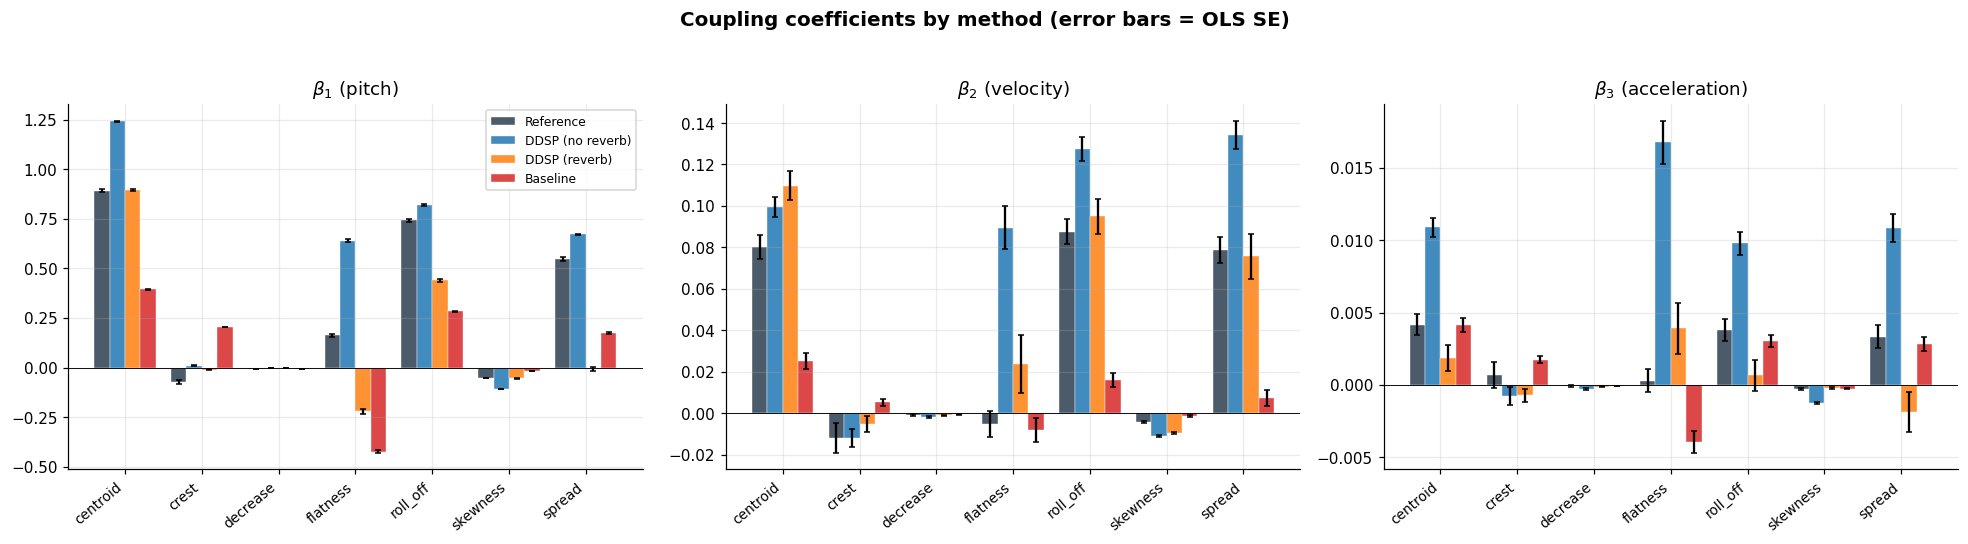

In [29]:
# Figure 1: Coefficient comparison bar chart — one panel per coefficient
C_REF_FIG = "#2c3e50"
all_labels = ["Reference", "DDSP (no reverb)", "DDSP (reverb)", "Baseline"]
fig_colors = {
    "Reference": C_REF_FIG,
    "DDSP (no reverb)": C_DDSP,
    "DDSP (reverb)": C_DDSP_R,
    "Baseline": C_BASE,
}

# Gather coefficients and SE per method per descriptor
# coeffs layout: [β0, β1(p), β2(p_dot), β3(p_ddot)]
coeff_data = {label: {} for label in all_labels}
se_data    = {label: {} for label in all_labels}

for d in DESCRIPTORS:
    m = ref_models[d]
    coeff_data["Reference"][d] = m["coeffs"]
    se_data["Reference"][d]    = m["se"]
    for label, mdict in all_method_models.items():
        coeff_data[label][d] = mdict[d]["coeffs"]
        se_data[label][d]    = mdict[d]["se"]

coeff_names = [r"$\beta_1$ (pitch)", r"$\beta_2$ (velocity)", r"$\beta_3$ (acceleration)"]
coeff_idx   = [1, 2, 3]  # indices into coeffs array

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
x = np.arange(len(DESCRIPTORS))
n = len(all_labels)
width = 0.8 / n

for ax, ci, cname in zip(axes, coeff_idx, coeff_names):
    for j, label in enumerate(all_labels):
        vals = [coeff_data[label][d][ci] for d in DESCRIPTORS]
        errs = [se_data[label][d][ci] for d in DESCRIPTORS]
        # Cap error bars for readability (NaN SE from L1 models won't appear)
        errs = [e if np.isfinite(e) else 0 for e in errs]
        offset = x + (j - (n - 1) / 2) * width
        ax.bar(offset, vals, width, yerr=errs, capsize=2,
               label=label, color=fig_colors[label], alpha=0.85,
               edgecolor="white", linewidth=0.3)
    ax.set_xticks(x)
    ax.set_xticklabels(DESC_SHORT, rotation=40, ha="right", fontsize=9)
    ax.set_title(cname, fontsize=12)
    ax.axhline(0, color="black", linewidth=0.6, linestyle="-")
    if ci == 1:
        ax.legend(fontsize=8, loc="best")

fig.suptitle("Coupling coefficients by method (error bars = OLS SE)", fontweight="bold", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(FIG_DIR / "coupling_coefficient_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

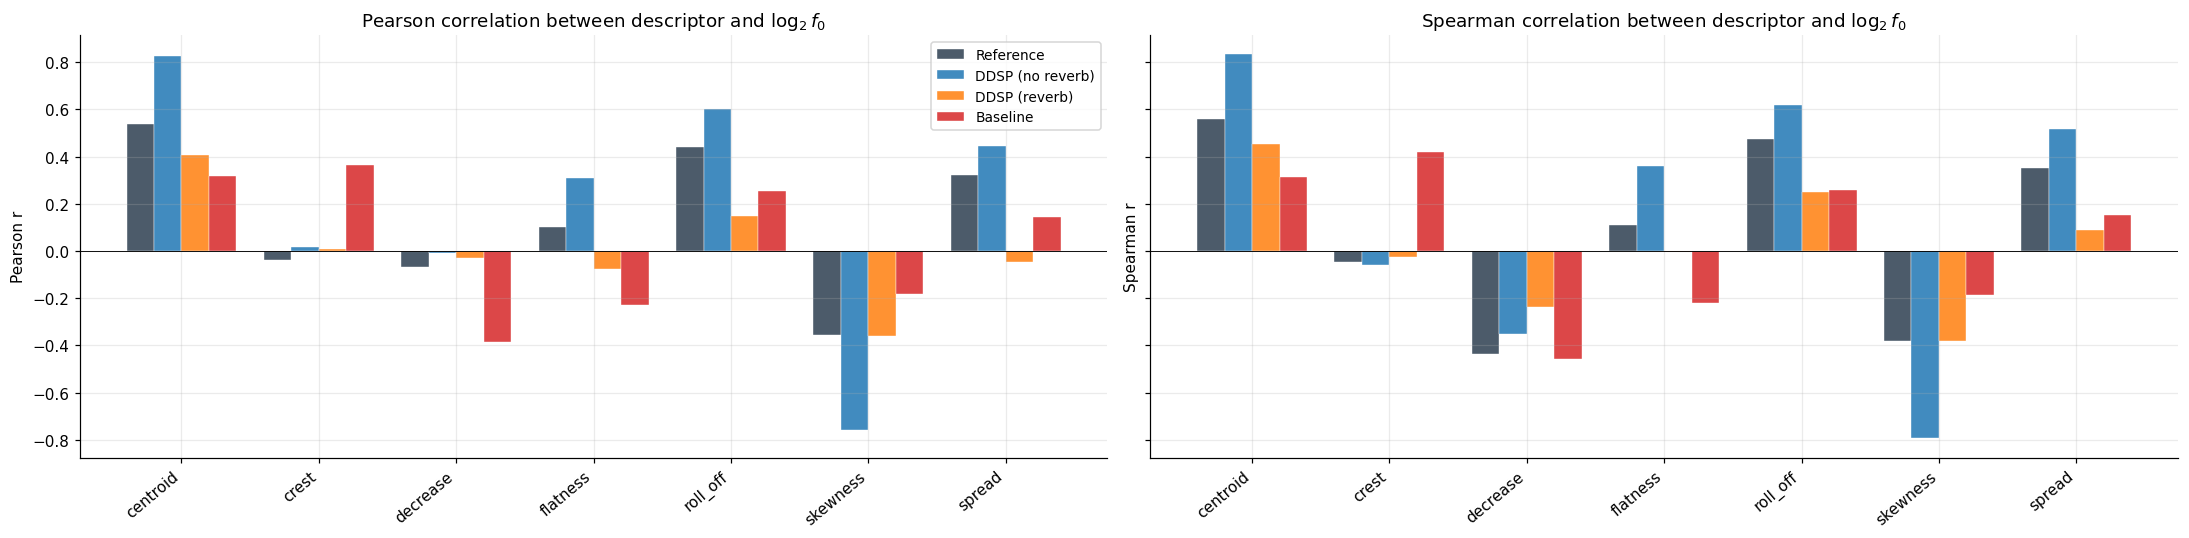

In [30]:
# Figure 2: descriptor↔pitch correlation comparison — Pearson and Spearman side-by-side.
corr_labels = ["Reference", "DDSP (no reverb)", "DDSP (reverb)", "Baseline"]

fig, axes = plt.subplots(1, 2, figsize=(20, 5), sharey=True)
x = np.arange(len(DESCRIPTORS))
n = len(corr_labels)
width = 0.8 / n

for ax, m in zip(axes, CORR_METHODS):
    df_c = df_corr_by_method[m]
    for j, label in enumerate(corr_labels):
        vals = df_c[label].values
        offset = x + (j - (n - 1) / 2) * width
        ax.bar(offset, vals, width, label=label, color=fig_colors[label],
               alpha=0.85, edgecolor="white", linewidth=0.3)
    ax.set_xticks(x)
    ax.set_xticklabels(DESC_SHORT, rotation=40, ha="right", fontsize=10)
    ax.axhline(0, color="black", linewidth=0.6)
    ax.set_title(
        f"{m.title()} correlation between descriptor and $\\log_2 f_0$",
        fontsize=12,
    )
    ax.set_ylabel(f"{m.title()} r")

axes[0].legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "coupling_correlation_comparison.png", dpi=160, bbox_inches="tight")
plt.show()


## 6. Dynamics Analysis

**Table 4** — Dynamics significance flags and dynamics distance.
**Figure 3** — Dynamics distance bar chart with significance markers.

In [31]:
# Table 4: Dynamics significance flags + dynamics distance
method_order_dyn = ["DDSP (no reverb)", "DDSP (reverb)", "Baseline"]

rows_t4 = []
for d in DESCRIPTORS:
    row = {"descriptor": d.replace("spectral_", "")}
    for label in method_order_dyn:
        dyn_row = df_dyn[(df_dyn.method == label) & (df_dyn.descriptor == d)]
        dd_row  = df_dd[(df_dd.method == label) & (df_dd.descriptor == d)]
        if len(dyn_row) == 0:
            row[f"{label}_b2_sig"] = "—"
            row[f"{label}_b3_sig"] = "—"
            row[f"{label}_dd"] = float("nan")
        else:
            r = dyn_row.iloc[0]
            row[f"{label}_b2_sig"] = "Y" if r["b3_significant"] else "N"  # b3_velocity = β₂
            row[f"{label}_b3_sig"] = "Y" if r["b4_significant"] else "N"  # b4_acceleration = β₃
            row[f"{label}_dd"] = dd_row.iloc[0]["dynamics_distance"] if len(dd_row) else float("nan")
    rows_t4.append(row)

# Summary row: count of descriptors with at least one significant dynamic term
summary_row = {"descriptor": r"\textit{significant / 7}"}
for label in method_order_dyn:
    count = 0
    for d in DESCRIPTORS:
        dyn_row = df_dyn[(df_dyn.method == label) & (df_dyn.descriptor == d)]
        if len(dyn_row) and (dyn_row.iloc[0]["b3_significant"] or dyn_row.iloc[0]["b4_significant"]):
            count += 1
    summary_row[f"{label}_b2_sig"] = str(count)
    summary_row[f"{label}_b3_sig"] = ""
    summary_row[f"{label}_dd"] = ""
rows_t4.append(summary_row)

df_t4 = pd.DataFrame(rows_t4)
display(df_t4)

# ── LaTeX ─────────────────────────────────────────────────────────────
short_labels = ["DDSP (no rev.)", "DDSP (rev.)", "Baseline"]
lines = [
    r"\begin{table}[ht]",
    r"\centering",
    r"\caption{Dynamics significance and distance to reference. Y/N indicates $p < 0.05$.}",
    r"\label{tab:dynamics}",
    r"\begin{tabular}{l" + "ccc" * len(method_order_dyn) + "}",
    r"\toprule",
]
# Header row 1: method names spanning 3 cols each
hdr1 = " & ".join([rf"\multicolumn{{3}}{{c}}{{{s}}}" for s in short_labels])
lines.append(f" & {hdr1} \\\\")
# cmidrule
for i, _ in enumerate(method_order_dyn):
    start = 2 + i * 3
    lines.append(rf"\cmidrule(lr){{{start}-{start+2}}}")
# Header row 2: sub-columns
sub = " & ".join([r"$\beta_2$ & $\beta_3$ & $\Delta\beta_{\mathrm{dyn}}$"] * len(method_order_dyn))
lines.append(f"Descriptor & {sub} \\\\")
lines.append(r"\midrule")

for row in rows_t4[:-1]:  # data rows
    parts = [row["descriptor"].replace("_", r"\_")]
    for label in method_order_dyn:
        dd = row[f"{label}_dd"]
        dd_str = f"{dd:.2f}" if isinstance(dd, float) and np.isfinite(dd) else "—"
        parts.append(f"{row[f'{label}_b2_sig']} & {row[f'{label}_b3_sig']} & {dd_str}")
    lines.append(" & ".join(parts) + r" \\")

# Summary row
lines.append(r"\midrule")
parts = [r"\textit{sig.\ descriptors}"]
for label in method_order_dyn:
    parts.append(f"\\multicolumn{{3}}{{c}}{{{summary_row[f'{label}_b2_sig']} / 7}}")
lines.append(" & ".join(parts) + r" \\")

lines += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]
print("\n".join(lines))

,descriptor,DDSP (no reverb)_b2_sig,DDSP (no reverb)_b3_sig,DDSP (no reverb)_dd,DDSP (reverb)_b2_sig,DDSP (reverb)_b3_sig,DDSP (reverb)_dd,Baseline_b2_sig,Baseline_b3_sig,Baseline_dd
0,centroid,Y,Y,0.020519,Y,Y,0.029891,Y,Y,0.054911
1,crest,Y,N,0.001468,N,N,0.006818,Y,Y,0.017205
2,decrease,Y,Y,0.00098,Y,Y,0.000086,Y,Y,0.000311
3,flatness,Y,Y,0.096089,N,Y,0.028959,N,Y,0.005167
4,roll_off,Y,Y,0.040302,Y,N,0.008022,Y,Y,0.071588
5,skewness,Y,Y,0.006618,Y,Y,0.005141,Y,Y,0.003021
6,spread,Y,Y,0.056231,Y,N,0.006055,Y,Y,0.071418
7,\textit{significant / 7},7,,,6,,,7,,


\begin{table}[ht]
\centering
\caption{Dynamics significance and distance to reference. Y/N indicates $p < 0.05$.}
\label{tab:dynamics}
\begin{tabular}{lccccccccc}
\toprule
 & \multicolumn{3}{c}{DDSP (no rev.)} & \multicolumn{3}{c}{DDSP (rev.)} & \multicolumn{3}{c}{Baseline} \\
\cmidrule(lr){2-4}
\cmidrule(lr){5-7}
\cmidrule(lr){8-10}
Descriptor & $\beta_2$ & $\beta_3$ & $\Delta\beta_{\mathrm{dyn}}$ & $\beta_2$ & $\beta_3$ & $\Delta\beta_{\mathrm{dyn}}$ & $\beta_2$ & $\beta_3$ & $\Delta\beta_{\mathrm{dyn}}$ \\
\midrule
centroid & Y & Y & 0.02 & Y & Y & 0.03 & Y & Y & 0.05 \\
crest & Y & N & 0.00 & N & N & 0.01 & Y & Y & 0.02 \\
decrease & Y & Y & 0.00 & Y & Y & 0.00 & Y & Y & 0.00 \\
flatness & Y & Y & 0.10 & N & Y & 0.03 & N & Y & 0.01 \\
roll\_off & Y & Y & 0.04 & Y & N & 0.01 & Y & Y & 0.07 \\
skewness & Y & Y & 0.01 & Y & Y & 0.01 & Y & Y & 0.00 \\
spread & Y & Y & 0.06 & Y & N & 0.01 & Y & Y & 0.07 \\
\midrule
\textit{sig.\ descriptors} & \multicolumn{3}{c}{7 / 7} & \multicolumn{3}

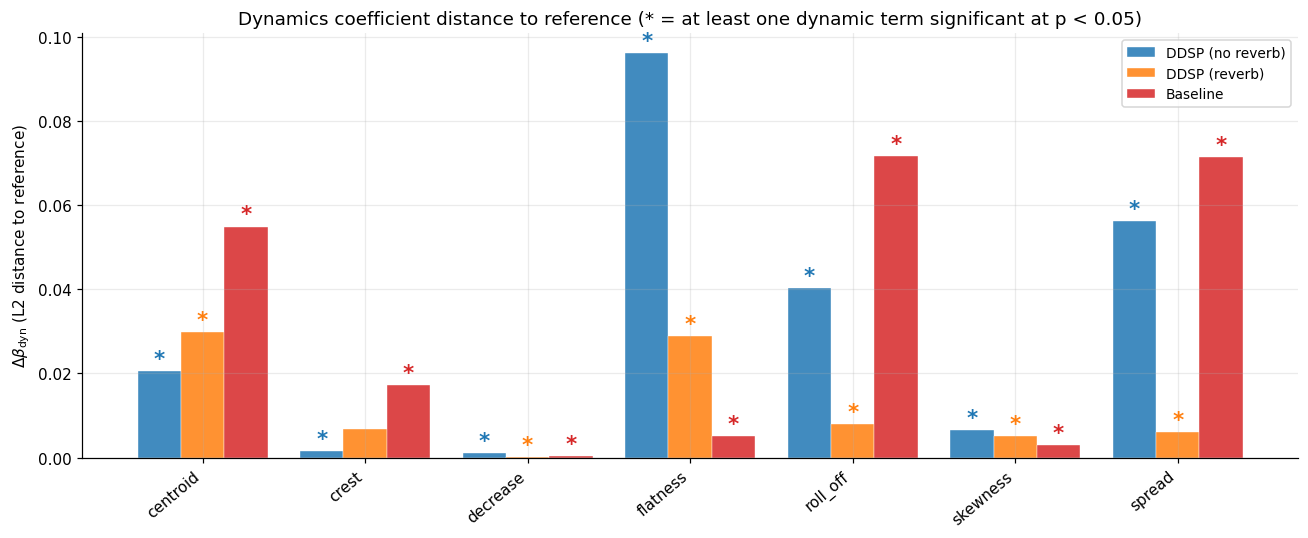

In [32]:
# Figure 3: Dynamics distance bar chart with significance markers
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(DESCRIPTORS))
n = len(method_order_dyn)
width = 0.8 / n

for j, label in enumerate(method_order_dyn):
    vals = []
    sigs = []  # True if at least one of β₂, β₃ is significant
    for d in DESCRIPTORS:
        dd_row = df_dd[(df_dd.method == label) & (df_dd.descriptor == d)]
        vals.append(dd_row.iloc[0]["dynamics_distance"] if len(dd_row) else 0)
        dyn_row = df_dyn[(df_dyn.method == label) & (df_dyn.descriptor == d)]
        if len(dyn_row):
            r = dyn_row.iloc[0]
            sigs.append(r["b3_significant"] or r["b4_significant"])
        else:
            sigs.append(False)

    offset = x + (j - (n - 1) / 2) * width
    color = fig_colors.get(label, f"C{j}")
    bars = ax.bar(offset, vals, width, label=label, color=color,
                  alpha=0.85, edgecolor="white", linewidth=0.3)

    # Significance markers
    for bar, sig in zip(bars, sigs):
        if sig:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + ax.get_ylim()[1] * 0.005,
                    "*", ha="center", va="bottom", fontsize=14,
                    fontweight="bold", color=color)

ax.set_xticks(x)
ax.set_xticklabels(DESC_SHORT, rotation=40, ha="right", fontsize=10)
ax.set_ylabel(r"$\Delta\beta_{\mathrm{dyn}}$ (L2 distance to reference)")
ax.set_title("Dynamics coefficient distance to reference (* = at least one dynamic term significant at p < 0.05)")
ax.legend(fontsize=9)

fig.tight_layout()
fig.savefig(FIG_DIR / "dynamics_distance_significance.png", dpi=160, bbox_inches="tight")
plt.show()